# Learned vs Fixed Metric — Small Examples w/ Auto Hyperparameter Search

This notebook reproduces the **small examples** workflow and augments it with **automatic hyperparameter search** for both the **fixed** and **learned** induced-metric optimizers. It also compares against the standard baselines used in the original analysis (SGD, Adam, AdamW, Muon when available).

Key points:

- Benchmarks: **Rosenbrock, Rastrigin, Himmelblau, Beale, Ackley** (2D).
- Stopping: stop when within `tol = 1e-10` of the known global minimum, or hit `max_steps`.
- Selection: among runs that reach tolerance, pick **lowest wall-time**; otherwise pick the run **closest to the minimum**.
- Fixed vs Learned:
  - Fixed: `optimisers/jax_fixed.py` (plain + optional log-loss & RMS variants).
  - Learned: `optimisers/jax_learnable.py` (plain + optional log-loss).

> This is designed to match the spirit of your original `small_examples.ipynb` and figures, while letting you search for the **optimal hyperparameters** of both families in one place.

In [18]:
# Imports & environment checks
import importlib, time, math, itertools, json
from dataclasses import dataclass
import numpy as np

import sys, os
# Add parent directory to path for importing optimisers
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

def _try(name):
    try:
        mod = importlib.import_module(name)
        print(f"OK: {name}")
        return mod
    except Exception as e:
        print(f"Missing: {name} -> {e}")
        return None

# Core (JAX/Optax focus, as in the paper)
jax   = _try("jax")
jnp   = _try("jax.numpy")
optax = _try("optax")

# Our optimisers
jax_fixed  = _try("optimisers.jax_fixed")        # fixed metric variants
jax_learn  = _try("optimisers.jax_learnable")    # learnable diag inverse metric

# Baselines
optax_muon = _try("optax.contrib.muon")          # optional

# Plotting
import matplotlib.pyplot as plt

print("Ready.")

OK: jax
OK: jax.numpy
OK: optax
OK: optimisers.jax_fixed
OK: optimisers.jax_learnable
Missing: optax.contrib.muon -> No module named 'optax.contrib.muon'
Ready.


## Benchmark functions (2D)

We use the same five classical functions as the original small examples:
**Rosenbrock, Rastrigin, Himmelblau, Beale, Ackley**.

In [19]:
# JAX definitions of the benchmarks
if jnp is not None:
    def rosenbrock(theta, a=1.0, b=100.0):
        x, y = theta[0], theta[1]
        return (a - x)**2 + b*(y - x**2)**2

    def rastrigin(theta, A=10.0):
        x, y = theta[0], theta[1]
        return 2*A + (x**2 - A*jnp.cos(2*jnp.pi*x)) + (y**2 - A*jnp.cos(2*jnp.pi*y))

    def himmelblau(theta):
        x, y = theta[0], theta[1]
        return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

    def beale(theta):
        x, y = theta[0], theta[1]
        term1 = (1.5 - x + x*y)
        term2 = (2.25 - x + x*y**2)
        term3 = (2.625 - x + x*y**3)
        return term1**2 + term2**2 + term3**2

    def ackley(theta, a=20.0, b=0.2, c=2*jnp.pi):
        x, y = theta[0], theta[1]
        term1 = -a * jnp.exp(-b * jnp.sqrt((x**2 + y**2)/2.0))
        term2 = -jnp.exp((jnp.cos(c*x) + jnp.cos(c*y))/2.0)
        return term1 + term2 + a + jnp.e

    BENCHES = {
        "rosenbrock": {"fn": rosenbrock,  "theta_star": jnp.array([1.0, 1.0]), "f_star": 0.0, "start": np.array([-1.2, 1.0], dtype=np.float32)},
        "rastrigin":  {"fn": rastrigin,   "theta_star": jnp.array([0.0, 0.0]), "f_star": 0.0, "start": np.array([3.0, 4.0], dtype=np.float32)},
        "himmelblau": {"fn": himmelblau,  "theta_star": jnp.array([3.0, 2.0]), "f_star": 0.0, "start": np.array([-2.0, 2.0], dtype=np.float32)},
        "beale":      {"fn": beale,       "theta_star": jnp.array([3.0, 0.5]), "f_star": 0.0, "start": np.array([-1.0, 1.0], dtype=np.float32)},
        "ackley":     {"fn": ackley,      "theta_star": jnp.array([0.0, 0.0]), "f_star": 0.0, "start": np.array([2.0, 2.0], dtype=np.float32)},
    }
else:
    BENCHES = {}

## Hyperparameter grids

We provide **default grids** that you can edit. For the small examples, the paper set `β=1` (no batching) and used **no weight decay**. We keep that here by default.

> You can shrink/enlarge these grids to trade off runtime vs thoroughness.

In [20]:
SEARCH = {
    # Fixed induced-metric (Alg. 1 plain)
    "fixed_plain": {
        "learning_rate": [0.001, 0.005, 0.01, 0.05, 0.1],
        "momentum":      [0.0, 0.5, 0.9],
        "xi":            [0.01, 0.1, 1.0],
        "beta":          [1.0],         # as per small examples (no EMA)
        "weight_decay":  [0.0],
    },
    # Learned diag inverse-metric
    "learn_plain": {
        "learning_rate": [0.001, 0.005, 0.01, 0.05, 0.1],
        "momentum":      [0.0, 0.5, 0.9],
        "xi":            [0.01, 0.1, 1.0],
        "beta":          [1.0],
        "weight_decay":  [0.0],
        "metric_lr":     [1e-3, 5e-4, 1e-4],
        "metric_reg":    [0.0, 1e-4],
        "metric_clip":   [4.0],
    },
    # Baselines
    "sgd": {
        "learning_rate": [0.001, 0.005, 0.01, 0.05, 0.1],
        "momentum":      [0.0, 0.5, 0.9],
        "weight_decay":  [0.0],
        "nesterov":      [False],
    },
    "adam": {
        "learning_rate": [0.0005, 0.001, 0.005, 0.01],
        "b1": [0.9], "b2": [0.999], "eps": [1e-8], "weight_decay":[0.0],
    },
    "adamw": {
        "learning_rate": [0.0005, 0.001, 0.005, 0.01],
        "b1": [0.9], "b2": [0.999], "eps": [1e-8], "weight_decay":[0.0, 1e-4],
    },
    # Optional Muon (if installed)
    "muon": {
        "learning_rate": [0.001, 0.005, 0.01],
    },
}

MAX_STEPS = 2000
TOL       = 1e-10
RNG_SEED  = 0

In [21]:
from typing import Dict, Any, Tuple

def rank_key(res: Dict[str, Any]):
    # Prefer converged; then faster runtime; then smaller final loss.
    return (
        0 if res["converged"] else 1,
        res["runtime_ms"],
        res["final_loss"],
    )

def grid_iter(space: Dict[str, list]):
    keys = list(space.keys())
    for values in itertools.product(*[space[k] for k in keys]):
        yield dict(zip(keys, values))

def as_float(x):
    try:
        return float(x)
    except Exception:
        return x

In [22]:
import jax
import jax.numpy as jnp
import optax

def make_vg(f):
    return jax.jit(jax.value_and_grad(f))

def run_optax_stepper(theta0, f, make_opt, update_fn, needs_loss=False, max_steps=MAX_STEPS, tol=TOL):
    vg = make_vg(lambda th: f(th))
    th = jnp.array(theta0)
    opt = make_opt(th)
    st  = opt.init(th)
    losses = []
    t0 = time.time()
    converged = False
    for step in range(1, max_steps+1):
        loss, grad = vg(th)
        if needs_loss:
            updates, st = update_fn(opt, grad, st, loss, th)
        else:
            updates, st = update_fn(opt, grad, st, None, th)
        th = optax.apply_updates(th, updates)
        losses.append(float(loss))
        if abs(float(loss)) <= tol:
            converged = True
            break
    ms = 1000.0*(time.time() - t0)
    return {
        "losses": losses,
        "runtime_ms": ms,
        "steps": step,
        "final_loss": losses[-1],
        "converged": converged,
    }

# Builders & update wrappers for each optimizer
def build_fixed_plain(hp):
    def make_opt(_params):
        return jax_fixed.custom_sgd(**hp)
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params=params)
    return make_opt, update_fn, False

def build_learn_plain(hp):
    def make_opt(_params):
        return jax_learn.custom_sgd_learnable_diag(**hp)
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params=params)
    return make_opt, update_fn, False

def build_sgd(hp):
    def make_opt(_params):
        return optax.sgd(learning_rate=hp["learning_rate"],
                            momentum=hp["momentum"],
                            nesterov=hp.get("nesterov", False))
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params=params) if hasattr(opt, "update") else (opt.update(grad, st), st)
    return make_opt, update_fn, False

def build_adam(hp):
    def make_opt(_params):
        return optax.adam(learning_rate=hp["learning_rate"], b1=hp["b1"], b2=hp["b2"], eps=hp["eps"])
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params=params) if hasattr(opt, "update") else (opt.update(grad, st), st)
    return make_opt, update_fn, False

def build_adamw(hp):
    def make_opt(_params):
        return optax.adamw(learning_rate=hp["learning_rate"], b1=hp["b1"], b2=hp["b2"], eps=hp["eps"], weight_decay=hp["weight_decay"])
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params=params) if hasattr(opt, "update") else (opt.update(grad, st), st)
    return make_opt, update_fn, False

def build_muon(hp):
    # Optional, may not exist in environment
    def make_opt(_params):
        return optax_muon.muon(learning_rate=hp["learning_rate"])
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params=params) if hasattr(opt, "update") else (opt.update(grad, st), st)
    return make_opt, update_fn, False

In [23]:
def search_one_function(name, max_steps=MAX_STEPS, tol=TOL):
    assert jnp is not None and jax_fixed is not None and jax_learn is not None, "Missing JAX or optimisers."
    bench = BENCHES[name]
    f = bench["fn"]
    start = bench["start"]

    results = {}

    # Fixed plain
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["fixed_plain"]):
        make_opt, update_fn, needs_loss = build_fixed_plain(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "fixed_plain", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["fixed_plain"] = best

    # Learned plain
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["learn_plain"]):
        make_opt, update_fn, needs_loss = build_learn_plain(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "learn_plain", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["learn_plain"] = best

    # Baselines
    # SGD
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["sgd"]):
        make_opt, update_fn, needs_loss = build_sgd(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "sgd", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["sgd"] = best

    # Adam
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["adam"]):
        make_opt, update_fn, needs_loss = build_adam(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "adam", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["adam"] = best

    # AdamW
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["adamw"]):
        make_opt, update_fn, needs_loss = build_adamw(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "adamw", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["adamw"] = best

    # Muon (optional)
    if optax_muon is not None:
        best = None; best_hp=None
        for hp in grid_iter(SEARCH["muon"]):
            make_opt, update_fn, needs_loss = build_muon(hp)
            out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
            rec = {"opt": "muon", "hp": hp, **out}
            if best is None or rank_key(rec) < rank_key(best):
                best, best_hp = rec, hp
        results["muon"] = best

    return results

In [21]:
ALL_RESULTS = {}

for name in BENCHES.keys():
    print("Searching:", name)
    ALL_RESULTS[name] = search_one_function(name, max_steps=MAX_STEPS, tol=TOL)

Searching: rosenbrock
Searching: rastrigin
Searching: rastrigin
Searching: himmelblau
Searching: himmelblau
Searching: beale
Searching: beale
Searching: ackley
Searching: ackley
Searching: himmelblau
Searching: beale
Searching: ackley


In [26]:
def plot_function_results(name, res):
    # Plot loss vs iteration for the best run of each optimizer (log y)
    plt.figure()
    plt.yscale("log")
    for k, r in res.items():
        if r is None: 
            continue
        plt.plot(r["losses"], label=k)
    plt.title(f"{name}: loss vs iteration (best per optimizer)")
    plt.xlabel("iteration"); plt.ylabel("loss")
    plt.legend()
    plt.show()

def summarize_table(res_all):
    import pandas as pd
    rows = []
    for fn_name, res in res_all.items():
        for k, r in res.items():
            if r is None: continue
            rows.append(dict(
                function = fn_name,
                optimizer = k,
                converged = r["converged"],
                steps = r["steps"],
                runtime_ms = round(r["runtime_ms"], 3),
                final_loss = r["final_loss"],
                hp = json.dumps({kk: float(vv) if isinstance(vv,(int,float)) else vv for kk,vv in r["hp"].items()})
            ))
    df = pd.DataFrame(rows)
    try:
        from caas_jupyter_tools import display_dataframe_to_user
        display_dataframe_to_user("learned_vs_fixed_grid_search_summary", df)
    except Exception:
        print(df)
    return df

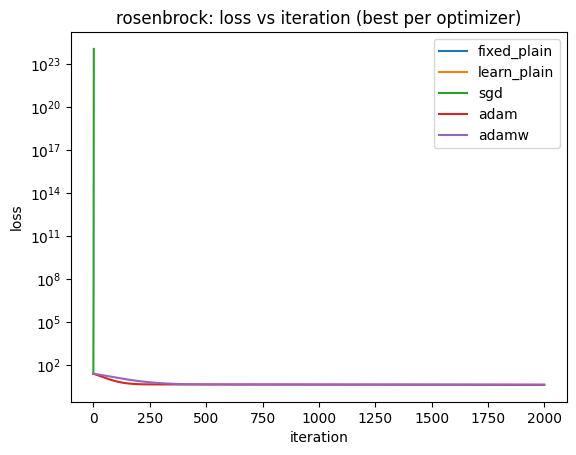

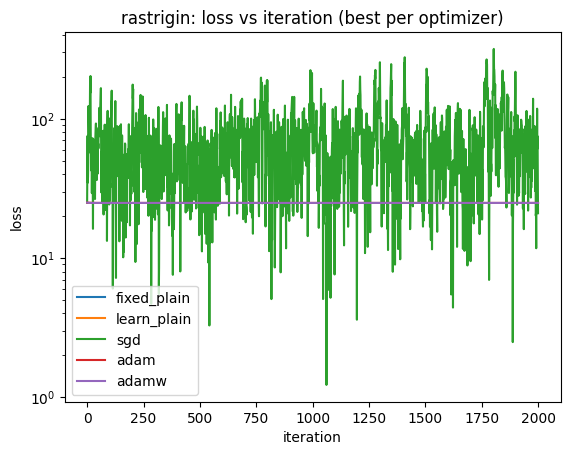

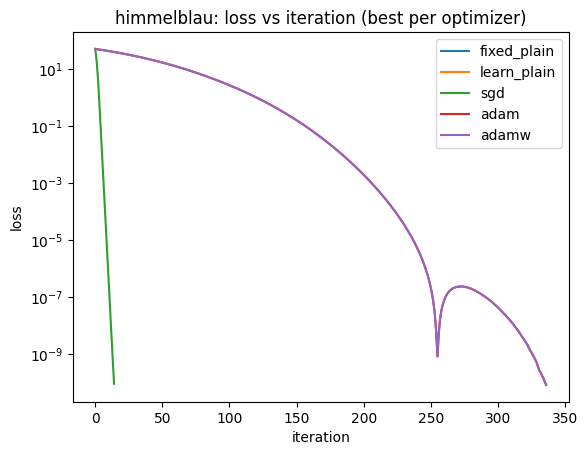

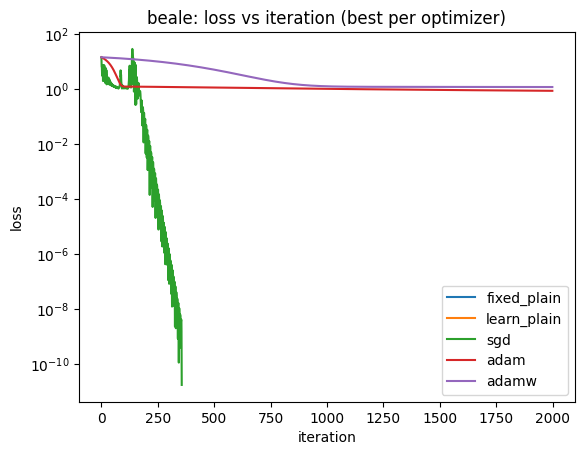

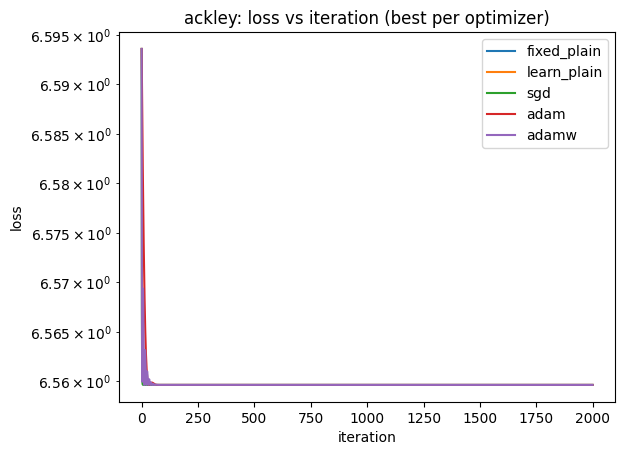

      function    optimizer  converged  steps  runtime_ms    final_loss  \
0   rosenbrock  fixed_plain      False   2000     164.623           NaN   
1   rosenbrock  learn_plain      False   2000     179.829           NaN   
2   rosenbrock          sgd      False   2000     179.773           NaN   
3   rosenbrock         adam      False   2000     691.650  3.949502e+00   
4   rosenbrock        adamw      False   2000     733.036  4.162097e+00   
5    rastrigin  fixed_plain      False   2000     171.303           NaN   
6    rastrigin  learn_plain      False   2000     182.066           NaN   
7    rastrigin          sgd      False   2000     180.411  2.097577e+01   
8    rastrigin         adam      False   2000     692.719  2.487384e+01   
9    rastrigin        adamw      False   2000     742.341  2.487384e+01   
10  himmelblau  fixed_plain      False   2000     169.984           NaN   
11  himmelblau  learn_plain      False   2000     180.253           NaN   
12  himmelblau          s

In [29]:
if len(ALL_RESULTS):
    for name, res in ALL_RESULTS.items():
        plot_function_results(name, res)
    _ = summarize_table(ALL_RESULTS)
else:
    print("No results to visualize.")

## Tips

- To reproduce the *exact* behavior of your original `small_examples`, you can set `MAX_STEPS`, `TOL`, and the starting points to match your prior setup. This notebook already uses the same stopping criterion and similar starts.
- The default grids are intentionally small. If you have time, **widen them**, especially for `xi` and the **learned metric**’s `metric_lr`.
- If Muon is not installed in your environment, that comparison will be skipped automatically.